<a href="https://colab.research.google.com/github/techstack-ujjwal/Therapeutic-Effectiveness-Prediction/blob/main/Therapeutic%20Effectiveness%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING IMPORTANT AND NECCESARLY LIBRARY

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv('train.csv')

In [57]:
df1 = df.drop(columns =['patient_id'], axis = 1 )

NOW WE WILL DO EDA FOR THIS DATA TO CHECK RELATION BETWWEN ALL ELEMENTS

In [58]:
df1.head()


,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,maslow_self_actualization,...,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,lifestyle_advice,duration_days,improvement_score,side_effects
0,69,Male,8,5,7,3,2,6,10,6,...,4,10,Kapha,Kapha Aggravation,"['Brahmi', 'Ashwagandha']","Cooling foods, avoid spicy","Yoga, Routine Sleep",14,92,True
1,41,Other,9,3,5,3,8,2,4,6,...,5,4,Vata-Kapha,Kapha Aggravation,"['Brahmi', 'Jatamansi']","Light diet, avoid fried foods","Pranayama, Meditation",28,55,True
2,34,Male,3,3,3,7,9,1,3,7,...,0,8,Vata-Kapha,Vata Aggravation,"['Amalaki', 'Shatavari']","Light diet, avoid fried foods","Meditation, Pranayama, Early Sleep",15,81,True
3,67,Female,3,7,3,1,5,9,2,10,...,0,9,Vata-Pitta,Pitta Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,"Pranayama, Meditation",14,89,False
4,46,Male,2,9,7,4,3,2,10,8,...,5,4,Pitta,Kapha Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,"Yoga, Routine Sleep",21,76,False


In [59]:
df1.shape

(400, 23)

In [60]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        400 non-null    int64 
 1   gender                     400 non-null    object
 2   stress_level               400 non-null    int64 
 3   anxiety_level              400 non-null    int64 
 4   depression_score           400 non-null    int64 
 5   maslow_physiological       400 non-null    int64 
 6   maslow_safety              400 non-null    int64 
 7   maslow_social              400 non-null    int64 
 8   maslow_esteem              400 non-null    int64 
 9   maslow_self_actualization  400 non-null    int64 
 10  sleep_hours                400 non-null    int64 
 11  exercise_frequency         400 non-null    int64 
 12  diet_type                  400 non-null    object
 13  caffeine_intake            400 non-null    int64 
 14  screen_tim

In [61]:
df1.isnull().sum()

,0
age,0
gender,0
stress_level,0
anxiety_level,0
depression_score,0
maslow_physiological,0
maslow_safety,0
maslow_social,0
maslow_esteem,0
maslow_self_actualization,0


from all this now i have known that my data doesnt consists of any null values it has 100 rows and 23 columns now  i will see some graphs and choose which data should i use and which shloud i drop

In [62]:
df1.columns

Index(['age', 'gender', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_esteem', 'maslow_self_actualization', 'sleep_hours',
       'exercise_frequency', 'diet_type', 'caffeine_intake',
       'screen_time_hours', 'prakriti', 'vikriti', 'herbs', 'diet_advice',
       'lifestyle_advice', 'duration_days', 'improvement_score',
       'side_effects'],
      dtype='object')

<Axes: xlabel='improvement_score', ylabel='Count'>

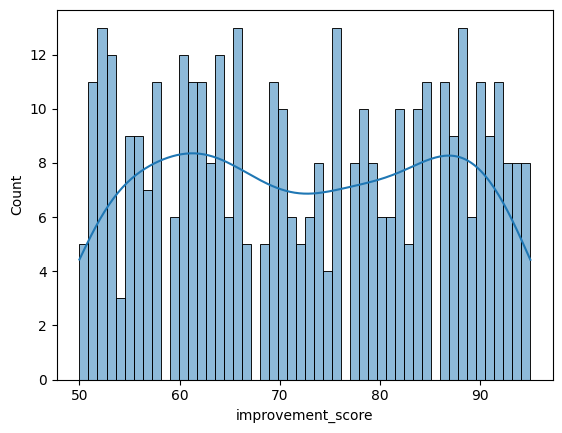

In [63]:
sns.histplot(df1['improvement_score'] ,bins= 50, kde= True)

In [64]:
df1.corr(numeric_only= True)

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,maslow_self_actualization,sleep_hours,exercise_frequency,caffeine_intake,screen_time_hours,duration_days,improvement_score,side_effects
age,1.000000,-0.019025,-0.028606,0.001628,0.077628,0.039357,0.002999,0.070532,-0.028407,-0.022437,0.036882,0.019544,0.015614,0.044719,0.105728,0.006166
stress_level,-0.019025,1.000000,0.067560,-0.000702,0.067399,0.012421,-0.029400,-0.034649,-0.033489,-0.028032,-0.001871,0.002872,-0.014739,0.035979,-0.108042,-0.059222
anxiety_level,-0.028606,0.067560,1.000000,-0.067409,0.117586,-0.021138,-0.015443,0.030527,-0.060697,-0.050808,0.012417,0.080572,0.028099,-0.073935,-0.028266,0.063746
depression_score,0.001628,-0.000702,-0.067409,1.000000,-0.123917,0.025662,-0.032849,-0.030015,-0.004871,-0.078285,0.054540,0.046694,-0.101012,0.028679,0.053652,0.064510
maslow_physiological,0.077628,0.067399,0.117586,-0.123917,1.000000,0.006570,-0.075128,-0.022971,-0.040456,-0.053610,0.124853,0.010373,0.023448,-0.042127,-0.033309,-0.064644
maslow_safety,0.039357,0.012421,-0.021138,0.025662,0.006570,1.000000,0.050778,-0.104324,0.131908,-0.045800,0.059255,-0.041463,-0.016965,0.047678,-0.052661,0.002103
maslow_social,0.002999,-0.029400,-0.015443,-0.032849,-0.075128,0.050778,1.000000,-0.039334,0.126894,0.041727,-0.080862,0.003920,0.003632,0.029941,-0.034412,-0.006863
maslow_esteem,0.070532,-0.034649,0.030527,-0.030015,-0.022971,-0.104324,-0.039334,1.000000,0.024513,-0.002194,-0.005822,0.086680,0.102026,-0.017690,0.004605,0.031976
maslow_self_actualization,-0.028407,-0.033489,-0.060697,-0.004871,-0.040456,0.131908,0.126894,0.024513,1.000000,-0.037997,0.048824,-0.098431,-0.070505,0.004304,0.017066,0.019137
sleep_hours,-0.022437,-0.028032,-0.050808,-0.078285,-0.053610,-0.045800,0.041727,-0.002194,-0.037997,1.000000,0.014087,0.008442,0.052087,-0.064823,0.065143,-0.040260


<Axes: >

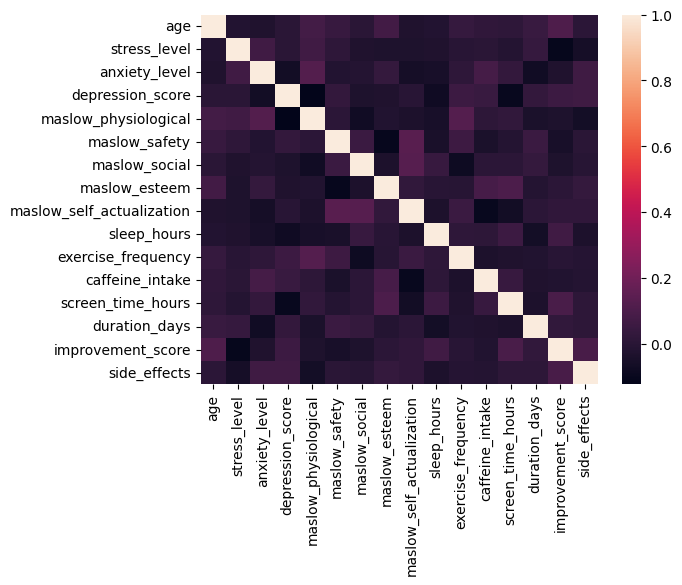

In [65]:
sns.heatmap(df1.corr(numeric_only= True))

from corelation i have analyzed that masloe_esteem and excercise  frequency have very low corelation with improvement score on the other hand age and stress level has a nice corelation

<Axes: xlabel='maslow_esteem', ylabel='improvement_score'>

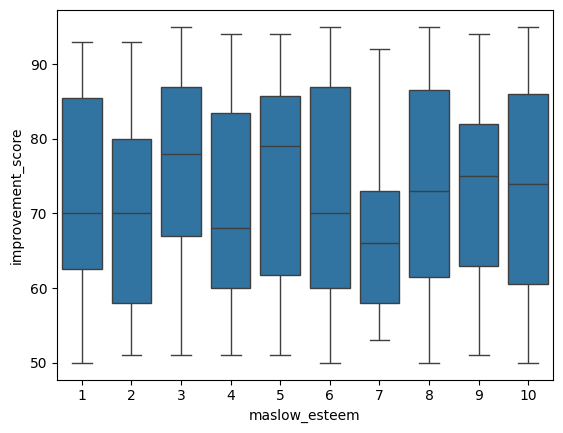

In [66]:
sns.boxplot(data= df1,x = 'maslow_esteem',y = 'improvement_score')


<Axes: xlabel='exercise_frequency', ylabel='improvement_score'>

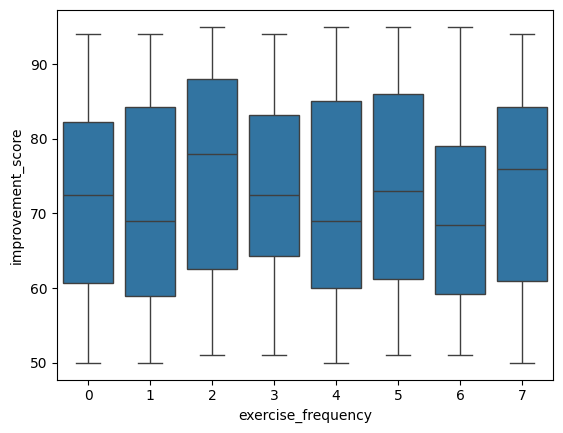

In [67]:
sns.boxplot(data= df1,x = 'exercise_frequency',y = 'improvement_score')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52],
 [Text(0, 0, '18'),
  Text(1, 0, '19'),
  Text(2, 0, '20'),
  Text(3, 0, '21'),
  Text(4, 0, '22'),
  Text(5, 0, '23'),
  Text(6, 0, '24'),
  Text(7, 0, '25'),
  Text(8, 0, '26'),
  Text(9, 0, '27'),
  Text(10, 0, '28'),
  Text(11, 0, '29'),
  Text(12, 0, '30'),
  Text(13, 0, '31'),
  Text(14, 0, '32'),
  Text(15, 0, '33'),
  Text(16, 0, '34'),
  Text(17, 0, '35'),
  Text(18, 0, '36'),
  Text(19, 0, '37'),
  Text(20, 0, '38'),
  Text(21, 0, '39'),
  Text(22, 0, '40'),
  Text(23, 0, '41'),
  Text(24, 0, '42'),
  Text(25, 0, '43'),
  Text(26, 0, '44'),
  Text(27, 0, '45'),
  Text(28, 0, '46'),
  Text(29, 0, '47'),
  Text(30, 0, '48'),
  Text(31, 0, '49'),
  Text(32, 0, '50'),
  Text(3

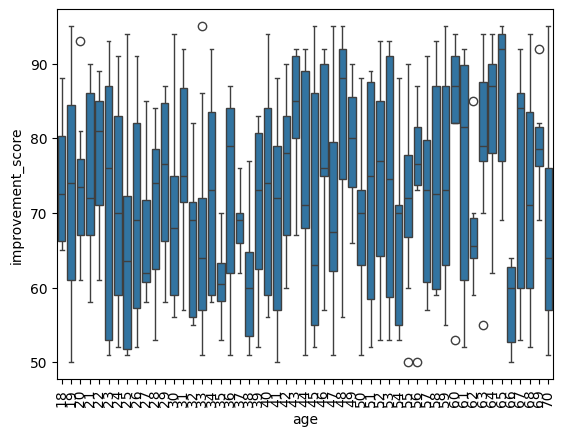

In [68]:
sns.boxplot(data= df1,x = 'age',y = 'improvement_score')
plt.xticks(rotation = 90)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10')])

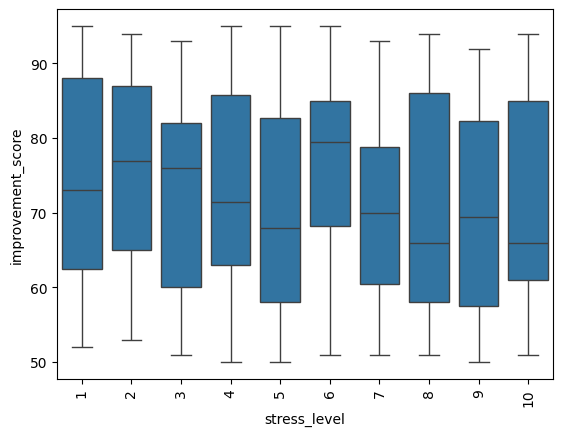

In [69]:
sns.boxplot(data= df1,x = 'stress_level',y = 'improvement_score')
plt.xticks(rotation = 90)

<Axes: xlabel='age', ylabel='improvement_score'>

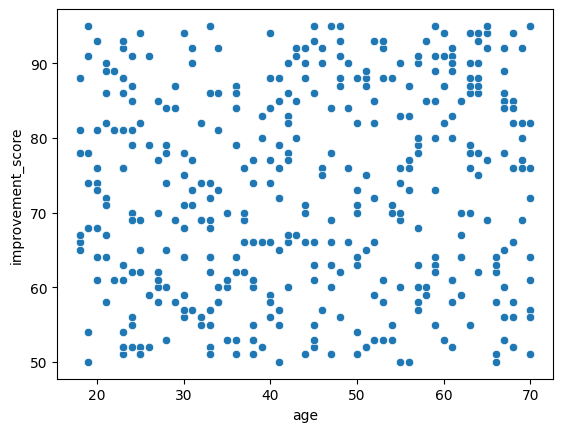

In [70]:
sns.scatterplot(x=df['age'], y = df['improvement_score'])

<Axes: xlabel='stress_level', ylabel='improvement_score'>

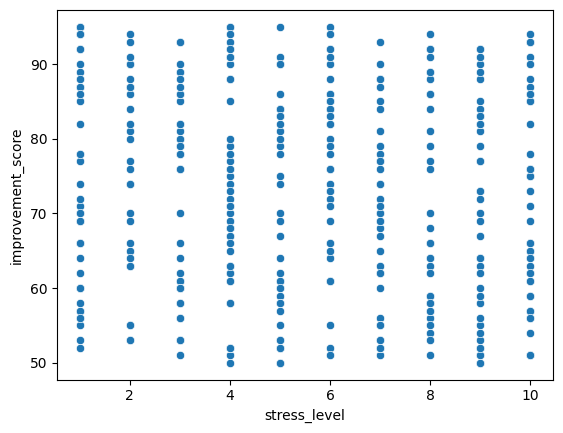

In [71]:
sns.scatterplot(x=df1['stress_level'], y = df['improvement_score'])

<Axes: xlabel='duration_days', ylabel='count'>

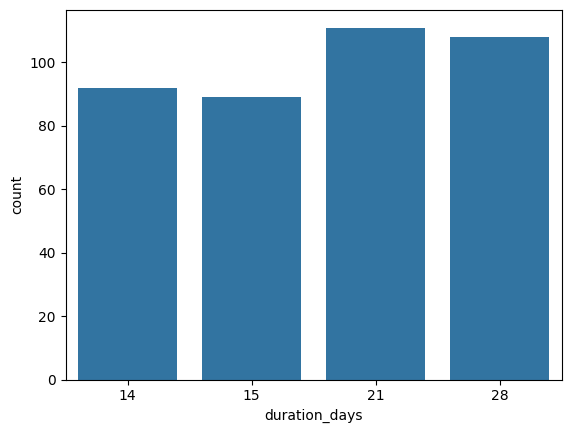

In [72]:
sns.countplot(x = df1['duration_days'] )

<Axes: xlabel='side_effects', ylabel='count'>

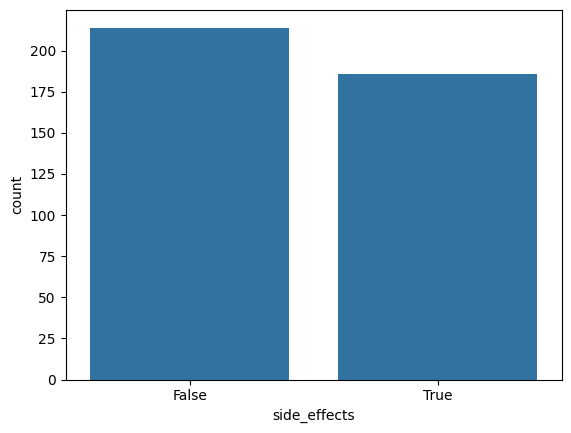

In [73]:
sns.countplot(x = df1['side_effects']  )

FEAUTURE SELECTION AND ENGINEEERING

now i will label encode and one hot encode the data set i will create two versions of this dataset and will see which performs better

In [74]:
X = df1.drop(columns = ['improvement_score','maslow_esteem', 'exercise_frequency'], axis = 1)
y = df1['improvement_score']

In [75]:
df1.head()

,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,maslow_self_actualization,...,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,lifestyle_advice,duration_days,improvement_score,side_effects
0,69,Male,8,5,7,3,2,6,10,6,...,4,10,Kapha,Kapha Aggravation,"['Brahmi', 'Ashwagandha']","Cooling foods, avoid spicy","Yoga, Routine Sleep",14,92,True
1,41,Other,9,3,5,3,8,2,4,6,...,5,4,Vata-Kapha,Kapha Aggravation,"['Brahmi', 'Jatamansi']","Light diet, avoid fried foods","Pranayama, Meditation",28,55,True
2,34,Male,3,3,3,7,9,1,3,7,...,0,8,Vata-Kapha,Vata Aggravation,"['Amalaki', 'Shatavari']","Light diet, avoid fried foods","Meditation, Pranayama, Early Sleep",15,81,True
3,67,Female,3,7,3,1,5,9,2,10,...,0,9,Vata-Pitta,Pitta Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,"Pranayama, Meditation",14,89,False
4,46,Male,2,9,7,4,3,2,10,8,...,5,4,Pitta,Kapha Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,"Yoga, Routine Sleep",21,76,False


In [76]:
df1.columns

Index(['age', 'gender', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_esteem', 'maslow_self_actualization', 'sleep_hours',
       'exercise_frequency', 'diet_type', 'caffeine_intake',
       'screen_time_hours', 'prakriti', 'vikriti', 'herbs', 'diet_advice',
       'lifestyle_advice', 'duration_days', 'improvement_score',
       'side_effects'],
      dtype='object')

i will do one hot encoding

In [77]:
X_encoded= pd.get_dummies(X, columns=['gender', 'prakriti','vikriti',  'diet_advice',"lifestyle_advice", 'side_effects','diet_type', 'herbs'], drop_first = True)

In [78]:
X_encoded

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,69,8,5,7,3,2,6,6,9,4,...,False,False,True,True,True,False,False,True,False,False
1,41,9,3,5,3,8,2,6,6,5,...,False,True,False,True,True,False,False,False,True,False
2,34,3,3,3,7,9,1,7,5,0,...,True,False,False,True,False,False,False,False,False,False
3,67,3,7,3,1,5,9,10,9,0,...,False,True,False,False,False,False,False,False,True,False
4,46,2,9,7,4,3,2,8,3,5,...,False,False,True,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,49,7,5,7,8,1,6,3,3,3,...,False,True,False,True,False,True,False,False,False,False
396,67,5,4,8,5,6,7,10,5,3,...,False,False,False,False,False,False,False,False,False,False
397,32,1,7,6,8,2,9,5,5,1,...,False,True,False,True,False,True,True,False,False,False
398,56,5,5,4,6,1,2,6,5,4,...,False,True,False,False,True,False,False,False,False,True


In [79]:
print(X_encoded.dtypes)

age                                                    int64
stress_level                                           int64
anxiety_level                                          int64
depression_score                                       int64
maslow_physiological                                   int64
maslow_safety                                          int64
maslow_social                                          int64
maslow_self_actualization                              int64
sleep_hours                                            int64
caffeine_intake                                        int64
screen_time_hours                                      int64
duration_days                                          int64
gender_Male                                             bool
gender_Other                                            bool
prakriti_Pitta                                          bool
prakriti_Pitta-Kapha                                    bool
prakriti_Vata           

In [80]:
X_encoded = X_encoded.astype(int)

In [81]:
X_encoded

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,69,8,5,7,3,2,6,6,9,4,...,0,0,1,1,1,0,0,1,0,0
1,41,9,3,5,3,8,2,6,6,5,...,0,1,0,1,1,0,0,0,1,0
2,34,3,3,3,7,9,1,7,5,0,...,1,0,0,1,0,0,0,0,0,0
3,67,3,7,3,1,5,9,10,9,0,...,0,1,0,0,0,0,0,0,1,0
4,46,2,9,7,4,3,2,8,3,5,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,49,7,5,7,8,1,6,3,3,3,...,0,1,0,1,0,1,0,0,0,0
396,67,5,4,8,5,6,7,10,5,3,...,0,0,0,0,0,0,0,0,0,0
397,32,1,7,6,8,2,9,5,5,1,...,0,1,0,1,0,1,1,0,0,0
398,56,5,5,4,6,1,2,6,5,4,...,0,1,0,0,1,0,0,0,0,1


In [82]:
X_encoded.sum().sort_values()

,0
prakriti_Vata,54
prakriti_Vata-Kapha,63
"herbs_['Brahmi', 'Jatamansi']",63
prakriti_Vata-Pitta,64
prakriti_Pitta-Kapha,68
prakriti_Pitta,70
"herbs_['Ashwagandha', 'Guduchi']",80
"herbs_['Brahmi', 'Ashwagandha']",86
vikriti_Vata Aggravation,87
"herbs_['Triphala', 'Guduchi']",89


In [83]:
X_encoded.shape


(400, 35)

In [84]:
#X_encoded = X_encoded.drop(columns=[
 #   'prakriti_Vata',
  #
  #  'prakriti_Vata-Pitta',
   # 'prakriti_Pitta-Kapha',
   # 'prakriti_Pitta',


   #'vikriti_Vata Aggravation',

   # 'diet_advice_Light diet, avoid fried foods',
   # 'lifestyle_advice_Pranayama, Meditation',
    #'vikriti_Kapha Aggravation',
 #   'lifestyle_advice_Yoga, Routine Sleep',
  #  'diet_advice_Cooling foods, avoid spicy'
#])

In [85]:
X_encoded.shape

(400, 35)

In [86]:
X_encoded.columns

Index(['age', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_self_actualization', 'sleep_hours', 'caffeine_intake',
       'screen_time_hours', 'duration_days', 'gender_Male', 'gender_Other',
       'prakriti_Pitta', 'prakriti_Pitta-Kapha', 'prakriti_Vata',
       'prakriti_Vata-Kapha', 'prakriti_Vata-Pitta',
       'vikriti_Kapha Aggravation', 'vikriti_Pitta Aggravation',
       'vikriti_Vata Aggravation', 'diet_advice_Cooling foods, avoid spicy',
       'diet_advice_Light diet, avoid fried foods',
       'diet_advice_Warm milk, early dinner',
       'lifestyle_advice_Meditation, Pranayama, Early Sleep',
       'lifestyle_advice_Pranayama, Meditation',
       'lifestyle_advice_Yoga, Routine Sleep', 'side_effects_True',
       'diet_type_Light', 'diet_type_Spicy',
       'herbs_['Ashwagandha', 'Guduchi']', 'herbs_['Brahmi', 'Ashwagandha']',
       'herbs_['Brahmi', 'Jatamansi']', 'herbs_['Triphala', '

In [87]:
X_encoded.head()

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,69,8,5,7,3,2,6,6,9,4,...,0,0,1,1,1,0,0,1,0,0
1,41,9,3,5,3,8,2,6,6,5,...,0,1,0,1,1,0,0,0,1,0
2,34,3,3,3,7,9,1,7,5,0,...,1,0,0,1,0,0,0,0,0,0
3,67,3,7,3,1,5,9,10,9,0,...,0,1,0,0,0,0,0,0,1,0
4,46,2,9,7,4,3,2,8,3,5,...,0,0,1,0,1,0,0,0,1,0


In [88]:
X_encoded.sum().sort_values()

,0
prakriti_Vata,54
prakriti_Vata-Kapha,63
"herbs_['Brahmi', 'Jatamansi']",63
prakriti_Vata-Pitta,64
prakriti_Pitta-Kapha,68
prakriti_Pitta,70
"herbs_['Ashwagandha', 'Guduchi']",80
"herbs_['Brahmi', 'Ashwagandha']",86
vikriti_Vata Aggravation,87
"herbs_['Triphala', 'Guduchi']",89


now i will do label encoding

In [89]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
Xlabel = X
data = ['gender', 'prakriti','vikriti', 'diet_advice',"lifestyle_advice", 'side_effects','diet_type','herbs']
for i in data :
    Xlabel[i] =encoder.fit_transform(Xlabel[i])

now i will use standard scalar on both data set to predict the standarize data set between -3 to +3

In [90]:
X_encoded.columns


Index(['age', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_self_actualization', 'sleep_hours', 'caffeine_intake',
       'screen_time_hours', 'duration_days', 'gender_Male', 'gender_Other',
       'prakriti_Pitta', 'prakriti_Pitta-Kapha', 'prakriti_Vata',
       'prakriti_Vata-Kapha', 'prakriti_Vata-Pitta',
       'vikriti_Kapha Aggravation', 'vikriti_Pitta Aggravation',
       'vikriti_Vata Aggravation', 'diet_advice_Cooling foods, avoid spicy',
       'diet_advice_Light diet, avoid fried foods',
       'diet_advice_Warm milk, early dinner',
       'lifestyle_advice_Meditation, Pranayama, Early Sleep',
       'lifestyle_advice_Pranayama, Meditation',
       'lifestyle_advice_Yoga, Routine Sleep', 'side_effects_True',
       'diet_type_Light', 'diet_type_Spicy',
       'herbs_['Ashwagandha', 'Guduchi']', 'herbs_['Brahmi', 'Ashwagandha']',
       'herbs_['Brahmi', 'Jatamansi']', 'herbs_['Triphala', '

In [91]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['age','stress_level','depression_score', 'maslow_safety',
       'sleep_hours',
      'screen_time_hours','anxiety_level',"maslow_physiological",'maslow_social','maslow_self_actualization','caffeine_intake']
scaler1= StandardScaler()
X_encoded[numerical_cols] = scaler1.fit_transform(X_encoded[numerical_cols])

In [92]:
X_encoded

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,1.581067,0.856241,-0.175514,0.575504,-0.919469,-1.186235,0.159307,0.157756,1.476972,0.910346,...,0,0,1,1,1,0,0,1,0,0
1,-0.208880,1.200458,-0.895570,-0.040008,-0.919469,0.902514,-1.218481,0.157756,-0.040465,1.517243,...,0,1,0,1,1,0,0,0,1,0
2,-0.656367,-0.864846,-0.895570,-0.655521,0.482962,1.250639,-1.562928,0.512264,-0.546277,-1.517243,...,1,0,0,1,0,0,0,0,0,0
3,1.453213,-0.864846,0.544543,-0.655521,-1.620684,-0.141861,1.192648,1.575788,1.476972,-1.517243,...,0,1,0,0,0,0,0,0,1,0
4,0.110753,-1.209064,1.264599,0.575504,-0.568861,-0.838111,-1.218481,0.866772,-1.557902,1.517243,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.302533,0.512023,-0.175514,0.575504,0.833570,-1.534360,0.159307,-0.905768,-1.557902,0.303449,...,0,1,0,1,0,1,0,0,0,0
396,1.453213,-0.176411,-0.535542,0.883261,-0.218253,0.206264,0.503754,1.575788,-0.546277,0.303449,...,0,0,0,0,0,0,0,0,0,0
397,-0.784221,-1.553281,0.544543,0.267748,0.833570,-1.186235,1.192648,-0.196752,-0.546277,-0.910346,...,0,1,0,1,0,1,1,0,0,0
398,0.750020,-0.176411,-0.175514,-0.347765,0.132354,-1.534360,-1.218481,0.157756,-0.546277,0.910346,...,0,1,0,0,1,0,0,0,0,1


In [93]:
Xlabel.columns

Index(['age', 'gender', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_self_actualization', 'sleep_hours', 'diet_type',
       'caffeine_intake', 'screen_time_hours', 'prakriti', 'vikriti', 'herbs',
       'diet_advice', 'lifestyle_advice', 'duration_days', 'side_effects'],
      dtype='object')

In [94]:
scaler= StandardScaler()
Xlabel[['age', 'gender', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_self_actualization', 'sleep_hours', 'diet_type',
       'caffeine_intake', 'screen_time_hours', 'prakriti', 'vikriti', 'herbs',
       'diet_advice', 'lifestyle_advice', 'duration_days', 'side_effects']]= scaler.fit_transform(Xlabel[['age', 'gender', 'stress_level', 'anxiety_level', 'depression_score',
       'maslow_physiological', 'maslow_safety', 'maslow_social',
       'maslow_self_actualization', 'sleep_hours', 'diet_type',
       'caffeine_intake', 'screen_time_hours', 'prakriti', 'vikriti', 'herbs',
       'diet_advice', 'lifestyle_advice', 'duration_days', 'side_effects']])

In [95]:
Xlabel

,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,lifestyle_advice,duration_days,side_effects
0,1.581067,0.018260,0.856241,-0.175514,0.575504,-0.919469,-1.186235,0.159307,0.157756,1.476972,-0.067345,0.910346,1.525233,-1.341762,-0.455327,0.005216,-0.407241,1.386242,-1.060982,1.072631
1,-0.208880,1.235625,1.200458,-0.895570,-0.040008,-0.919469,0.902514,-1.218481,0.157756,-0.040465,-0.067345,1.517243,-0.759760,0.942088,-0.455327,0.700694,0.468546,0.497625,1.437546,1.072631
2,-0.656367,0.018260,-0.864846,-0.895570,-0.655521,0.482962,1.250639,-1.562928,0.512264,-0.546277,-1.291807,-1.517243,0.763569,0.942088,1.393718,-1.385739,0.468546,-0.390991,-0.882516,1.072631
3,1.453213,-1.199104,-0.864846,0.544543,-0.655521,-1.620684,-0.141861,1.192648,1.575788,1.476972,-1.291807,-1.517243,1.144401,1.513051,0.469195,0.700694,-1.283028,0.497625,-1.060982,-0.932287
4,0.110753,0.018260,-1.209064,1.264599,0.575504,-0.568861,-0.838111,-1.218481,0.866772,-1.557902,-0.067345,1.517243,-0.759760,-0.770800,-0.455327,0.700694,-1.283028,1.386242,0.188282,-0.932287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.302533,0.018260,0.512023,-0.175514,0.575504,0.833570,-1.534360,0.159307,-0.905768,-1.557902,1.157116,0.303449,1.525233,-1.341762,1.393718,-1.385739,-1.283028,0.497625,1.437546,1.072631
396,1.453213,0.018260,-0.176411,-0.535542,0.883261,-0.218253,0.206264,0.503754,1.575788,-0.546277,-1.291807,0.303449,-1.521425,0.942088,0.469195,-1.385739,1.344334,-1.279608,0.188282,-0.932287
397,-0.784221,-1.199104,-1.553281,0.544543,0.267748,0.833570,-1.186235,1.192648,-0.196752,-0.546277,1.157116,-0.910346,0.763569,-0.770800,-0.455327,-0.690262,-1.283028,0.497625,0.188282,1.072631
398,0.750020,-1.199104,-0.176411,-0.175514,-0.347765,0.132354,-1.534360,-1.218481,0.157756,-0.546277,-0.067345,0.910346,0.763569,-1.341762,-1.379850,1.396171,0.468546,0.497625,0.188282,-0.932287


NOW WE ARE GOING TO CREATE MODEL  I WILL USE TO ALGORITHM RANDOM FOREST regressor BECAUSE HERE ARE MULTIPLE COLUMNS and  improvement score as continous varaible

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score


In [97]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [98]:
X_encoded

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,1.581067,0.856241,-0.175514,0.575504,-0.919469,-1.186235,0.159307,0.157756,1.476972,0.910346,...,0,0,1,1,1,0,0,1,0,0
1,-0.208880,1.200458,-0.895570,-0.040008,-0.919469,0.902514,-1.218481,0.157756,-0.040465,1.517243,...,0,1,0,1,1,0,0,0,1,0
2,-0.656367,-0.864846,-0.895570,-0.655521,0.482962,1.250639,-1.562928,0.512264,-0.546277,-1.517243,...,1,0,0,1,0,0,0,0,0,0
3,1.453213,-0.864846,0.544543,-0.655521,-1.620684,-0.141861,1.192648,1.575788,1.476972,-1.517243,...,0,1,0,0,0,0,0,0,1,0
4,0.110753,-1.209064,1.264599,0.575504,-0.568861,-0.838111,-1.218481,0.866772,-1.557902,1.517243,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.302533,0.512023,-0.175514,0.575504,0.833570,-1.534360,0.159307,-0.905768,-1.557902,0.303449,...,0,1,0,1,0,1,0,0,0,0
396,1.453213,-0.176411,-0.535542,0.883261,-0.218253,0.206264,0.503754,1.575788,-0.546277,0.303449,...,0,0,0,0,0,0,0,0,0,0
397,-0.784221,-1.553281,0.544543,0.267748,0.833570,-1.186235,1.192648,-0.196752,-0.546277,-0.910346,...,0,1,0,1,0,1,1,0,0,0
398,0.750020,-0.176411,-0.175514,-0.347765,0.132354,-1.534360,-1.218481,0.157756,-0.546277,0.910346,...,0,1,0,0,1,0,0,0,0,1


RANDOM FOREST

In [99]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(

    n_estimators=100,
    max_depth=15,

    random_state=42,

)



In [100]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, random_state=42)

In [101]:
y_pred2= rf_model.predict(X_test)

In [102]:
y_pred2

array([79.78      , 69.12666667, 76.06666667, 71.04333333, 73.37416667,
       70.93555556, 70.23      , 66.55      , 70.96      , 70.08333333,
       67.32477778, 72.10555556, 76.66555556, 74.78      , 70.46      ,
       70.19      , 77.51714286, 72.725     , 72.        , 69.6       ,
       74.02      , 68.36      , 73.64      , 68.62      , 73.25      ,
       74.634     , 72.99      , 71.85      , 74.54      , 73.34      ,
       80.01      , 67.885     , 78.92      , 70.31      , 75.8       ,
       68.05      , 68.22555556, 67.7       , 75.42      , 74.45      ,
       70.54      , 73.58      , 71.28      , 76.055     , 72.812     ,
       71.81      , 72.55      , 76.61      , 68.74333333, 73.83      ,
       77.125     , 78.06      , 73.61166667, 71.52      , 77.13      ,
       70.12133333, 71.59      , 71.91333333, 73.34833333, 75.22      ,
       71.79      , 67.22555556, 72.44      , 76.5       , 77.        ,
       77.7       , 69.18333333, 77.28      , 73.75      , 71.79

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score ,root_mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("MSE:", mean_squared_error(y_test, y_pred2))

rmse_value_1 = root_mean_squared_error(y_test, y_pred2)
print(f"RMSE using root_mean_squared_error: {rmse_value_1}")


MAE: 11.075618452380953
MSE: 169.85067180939942
RMSE using root_mean_squared_error: 13.032677077615306


checking model on test file

In [104]:
test_df = pd.read_csv("test.csv")

In [105]:
patient_ids = test_df["patient_id"]

In [106]:
test_df = test_df.drop("patient_id", axis=1)

In [107]:
test_df = pd.get_dummies(test_df)
test_df = test_df.reindex(columns=X_encoded.columns, fill_value=0)

In [108]:
test_df= test_df.astype(int)


In [109]:
test_df

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,40,2,5,10,1,6,1,7,3,5,...,1,0,0,0,0,1,0,1,0,0
1,66,7,5,0,7,4,3,1,8,4,...,1,0,0,0,0,1,0,0,1,0
2,42,10,4,0,9,10,5,1,8,5,...,0,0,0,0,0,1,0,0,0,0
3,58,2,9,0,1,6,3,3,3,0,...,0,1,0,0,1,0,0,0,0,1
4,52,9,9,5,5,6,6,7,9,5,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,63,10,1,0,3,7,2,4,9,0,...,0,0,1,0,1,0,0,0,0,1
96,39,7,5,6,10,7,4,3,4,2,...,1,0,0,0,1,0,0,1,0,0
97,18,8,8,2,5,1,10,3,3,2,...,1,0,0,0,1,0,0,0,0,1
98,25,6,1,8,6,3,1,8,4,4,...,0,0,1,0,1,0,0,1,0,0


In [110]:

test_df[numerical_cols] = scaler1.transform(test_df[numerical_cols])

In [111]:
test_df

,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_self_actualization,sleep_hours,caffeine_intake,...,"lifestyle_advice_Meditation, Pranayama, Early Sleep","lifestyle_advice_Pranayama, Meditation","lifestyle_advice_Yoga, Routine Sleep",side_effects_True,diet_type_Light,diet_type_Spicy,"herbs_['Ashwagandha', 'Guduchi']","herbs_['Brahmi', 'Ashwagandha']","herbs_['Brahmi', 'Jatamansi']","herbs_['Triphala', 'Guduchi']"
0,-0.272807,-1.209064,-0.175514,1.498774,-1.620684,0.206264,-1.562928,0.512264,-1.557902,1.517243,...,1,0,0,0,0,1,0,1,0,0
1,1.389287,0.512023,-0.175514,-1.578790,0.482962,-0.489986,-0.874034,-1.614784,0.971160,0.910346,...,1,0,0,0,0,1,0,0,1,0
2,-0.144954,1.544676,-0.535542,-1.578790,1.184177,1.598763,-0.185140,-1.614784,0.971160,1.517243,...,0,0,0,0,0,1,0,0,0,0
3,0.877873,-1.209064,1.264599,-1.578790,-1.620684,0.206264,-0.874034,-0.905768,-1.557902,-1.517243,...,0,1,0,0,1,0,0,0,0,1
4,0.494313,1.200458,1.264599,-0.040008,-0.218253,0.206264,0.159307,0.512264,1.476972,1.517243,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.197507,1.544676,-1.615626,-1.578790,-0.919469,0.554389,-1.218481,-0.551260,1.476972,-1.517243,...,0,0,1,0,1,0,0,0,0,1
96,-0.336734,0.512023,-0.175514,0.267748,1.534785,0.554389,-0.529587,-0.905768,-1.052090,-0.303449,...,1,0,0,0,1,0,0,1,0,0
97,-1.679194,0.856241,0.904571,-0.963278,-0.218253,-1.534360,1.537095,-0.905768,-1.557902,-0.303449,...,1,0,0,0,1,0,0,0,0,1
98,-1.231707,0.167806,-1.615626,0.883261,0.132354,-0.838111,-1.562928,0.866772,-1.052090,0.910346,...,0,0,1,0,1,0,0,1,0,0


In [112]:
predictions = rf_model.predict(test_df)

In [113]:
predictions

array([72.252     , 73.745     , 66.21      , 67.76666667, 69.55555556,
       74.54      , 69.914     , 70.24      , 73.12571429, 73.13      ,
       71.8       , 67.9125    , 73.696     , 72.65      , 74.86      ,
       70.118     , 68.394     , 74.71      , 70.70702381, 74.95714286,
       74.22      , 72.23855556, 70.225     , 73.80666667, 72.17      ,
       78.52      , 76.31      , 63.90333333, 69.17833333, 73.85      ,
       67.56      , 72.83      , 70.66      , 75.045     , 75.95      ,
       71.34666667, 78.3       , 72.83      , 71.64      , 69.635     ,
       71.44222222, 69.69555556, 73.12      , 70.863     , 73.96      ,
       70.7905    , 73.21055556, 76.51      , 74.36      , 71.69      ,
       79.86      , 75.76      , 75.32      , 72.8       , 68.74      ,
       69.583     , 71.45      , 74.66      , 72.3335    , 74.80333333,
       74.35      , 70.77      , 75.93      , 72.1       , 69.28      ,
       69.53055556, 75.47      , 66.791     , 71.36555556, 80.89